# Song Popularity Prediction on Spotify Dataset

## Import Libraries

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

## Load Dataset

In [242]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [243]:
from google.colab import files
uploaded = files.upload()

Saving spotify.zip to spotify (5).zip


In [244]:
import zipfile
import os

zip_file = "spotify.zip"

extract_dir = "/content/extracted/"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
  zip_ref.extractall(extract_dir)

print(f"Files extracted to {extract_dir}")

Files extracted to /content/extracted/


In [245]:
high_popularity_path = os.path.join(extract_dir, "high_popularity_spotify_data.csv")
low_popularity_path = os.path.join(extract_dir, "low_popularity_spotify_data.csv")
high_popularity = pd.read_csv(high_popularity_path)
low_popularity = pd.read_csv(low_popularity_path)

## Data Preprocessing

In [246]:
high_popularity['popularity'] = 1
low_popularity['popularity'] = 0

In [247]:
df = pd.concat([high_popularity, low_popularity], ignore_index=True)

In [248]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

In [249]:
df.head(10)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
5,0.582,116.712,0.700,pop,-5.960,0.0881,0.785,Chappell Roan,4.0,0.0356,...,1WAjjRMfZjEXtB0lQrAw6Q,0.0,11.0,218424.0,0.0502,0WbMK4wrZ1wFSty9F7FCgu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
6,0.561,150.069,0.669,pop,-6.538,0.0954,0.841,Addison Rae,4.0,0.0411,...,0XA403JTounqFh2owquBXu,1.0,10.0,169698.0,0.4950,6MzofobZt2dm0Kf1hTThFz,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
7,0.247,148.101,0.467,pop,-12.002,0.1700,0.126,Billie Eilish,4.0,0.0431,...,7aJuG4TFXa2hmE4z1yxc3n,0.0,6.0,261467.0,0.6120,3QaPy1KgI7nu9FJEQUgn6h,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
8,0.416,94.926,0.492,pop,-10.439,0.2030,0.297,Gigi Perez,4.0,0.0254,...,4DWrYvfGXRE8ko5ZxlIpit,1.0,11.0,211979.0,0.6860,0UYnhUfnUj5adChuAXvLUB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
9,0.722,119.973,0.769,pop,-5.485,0.1110,0.570,"The Weeknd, Playboi Carti",4.0,0.0507,...,2IRxVVqbSbqHJo8Zx50LYn,0.0,11.0,256000.0,0.0584,1Es7AUAhQvapIcoh3qMKDL,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


In [250]:
df['playlist_genre'].unique()

array(['pop', 'rock', 'jazz', 'classical', 'hip-hop', 'afrobeats',
       'latin', 'indian', 'country', 'r&b', 'electronic', 'soul',
       'gaming', 'j-pop', 'metal', 'reggae', 'k-pop', 'arabic', 'punk',
       'blues', 'folk', 'lofi', 'brazilian', 'turkish', 'ambient',
       'korean', 'world', 'indie', 'mandopop', 'cantopop', 'wellness',
       'gospel', 'funk', 'soca', 'disco'], dtype=object)

In [251]:
df['playlist_subgenre'].unique()

array(['mainstream', 'classic', 'essential', 'modern', 'gangster', 'trap',
       'nigerian', 'hip-hop', 'bollywood', 'indie', 'feel-good',
       'african', 'anime', '90s', '80s', 'french', 'global', 'chill',
       'soft', 'throwback', 'bedroom', 'alternative', 'heavy', 'death',
       'pop punk', 'southern', 'american', 'bhangra', 'tropical',
       'techno', 'future bass', 'deep house', 'cumbia', 'reggaeton',
       'funk', 'pop', 'meditative', 'academic', 'melodic', 'drama',
       'throat singing', 'nordic', 'desi', 'fusion', 'afro house',
       'neo-classical', 'vaporwave', 'drill', 'spanish', 'workout',
       'australian', 'afro-latin', 'scandi', 'delta', 'classical',
       'smooth', 'retro', 'forró', 'irish', 'yoga', 'cinematic',
       'soundtracks', 'choral', 'celtic', 'latin', 'tango', 'cajun',
       'klezmer', 'experimental', 'hardstyle', 'avant-garde', 'future',
       'grime', 'gqom', 'carnival', 'italo', 'post-rock', 'indigenous',
       'jewish', 'japanese', 'noir'

In [252]:
le_genre = LabelEncoder()
le_subgenre = LabelEncoder()

In [253]:
df['playlist_genre'] = le_genre.fit_transform(df['playlist_genre'])
df['playlist_subgenre'] = le_genre.fit_transform(df['playlist_subgenre'])

In [254]:
df = df.select_dtypes(exclude=['object'])
df = df.dropna()

In [255]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4830 entries, 0 to 4830
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   energy             4830 non-null   float64
 1   tempo              4830 non-null   float64
 2   danceability       4830 non-null   float64
 3   playlist_genre     4830 non-null   int64  
 4   loudness           4830 non-null   float64
 5   liveness           4830 non-null   float64
 6   valence            4830 non-null   float64
 7   time_signature     4830 non-null   float64
 8   speechiness        4830 non-null   float64
 9   track_popularity   4830 non-null   int64  
 10  instrumentalness   4830 non-null   float64
 11  mode               4830 non-null   float64
 12  key                4830 non-null   float64
 13  duration_ms        4830 non-null   float64
 14  acousticness       4830 non-null   float64
 15  playlist_subgenre  4830 non-null   int64  
 16  popularity         4830 non-n

In [256]:
df.head(30)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,duration_ms,acousticness,playlist_subgenre,popularity
0,0.592,157.969,0.521,25,-7.777,0.1220,0.535,3.0,0.0304,100,0.000000,0.0,6.0,251668.0,0.30800,55,1
1,0.507,104.978,0.747,25,-10.171,0.1170,0.438,4.0,0.0358,97,0.060800,1.0,2.0,210373.0,0.20000,55,1
2,0.808,108.548,0.554,25,-4.169,0.1590,0.372,4.0,0.0368,93,0.000000,1.0,1.0,166300.0,0.21400,55,1
3,0.910,112.966,0.670,25,-4.070,0.3040,0.786,4.0,0.0634,81,0.000000,0.0,0.0,157280.0,0.09390,55,1
4,0.783,149.027,0.777,25,-4.477,0.3550,0.939,4.0,0.2600,98,0.000000,0.0,0.0,169917.0,0.02830,55,1
5,0.582,116.712,0.700,25,-5.960,0.0881,0.785,4.0,0.0356,94,0.000000,0.0,11.0,218424.0,0.05020,55,1
6,0.561,150.069,0.669,25,-6.538,0.0954,0.841,4.0,0.0411,88,0.009620,1.0,10.0,169698.0,0.49500,55,1
7,0.247,148.101,0.467,25,-12.002,0.1700,0.126,4.0,0.0431,93,0.000271,0.0,6.0,261467.0,0.61200,55,1
8,0.416,94.926,0.492,25,-10.439,0.2030,0.297,4.0,0.0254,71,0.000086,1.0,11.0,211979.0,0.68600,55,1
9,0.722,119.973,0.769,25,-5.485,0.1110,0.570,4.0,0.0507,92,0.000003,0.0,11.0,256000.0,0.05840,55,1


## Exploratory Data Analysis

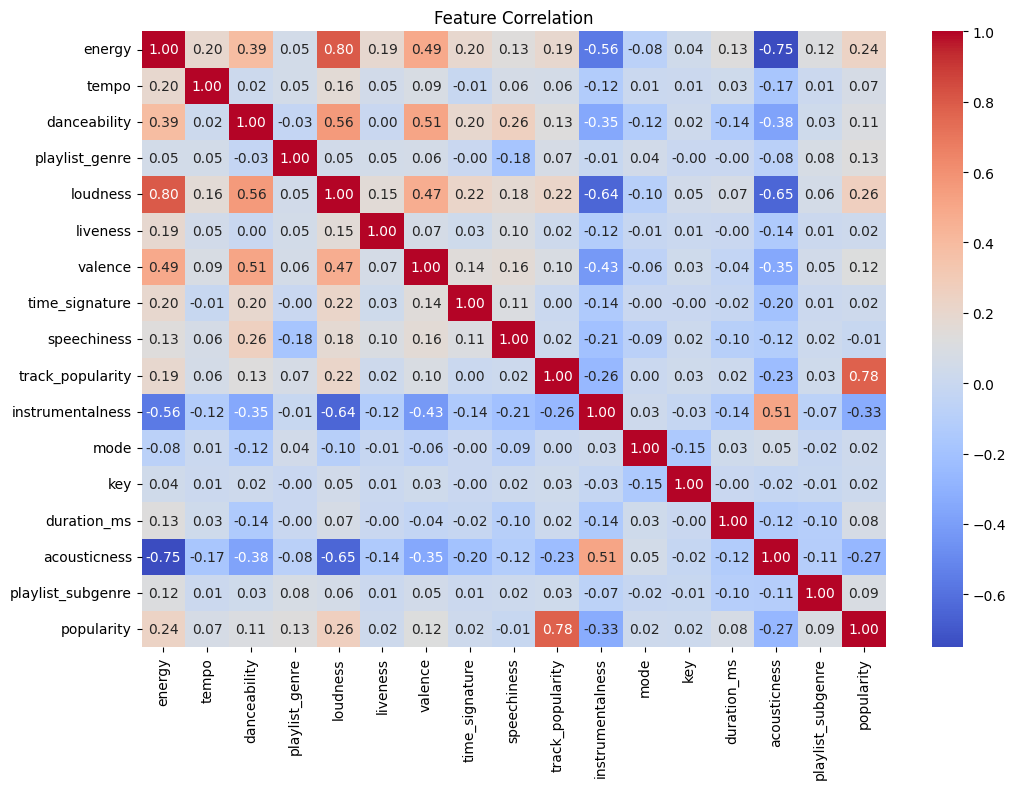

In [257]:
numerical_features = df.columns
df[numerical_features].describe()

plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="coolwarm", fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [258]:
correlation_threshold = 0.2
correlations = df[numerical_features].corr()['popularity']
relevant_features = correlations[abs(correlations) > correlation_threshold].index.tolist()
relevant_features.remove('popularity')

print('Relevant features based on the correlation:', relevant_features)

Relevant features based on the correlation: ['energy', 'loudness', 'track_popularity', 'instrumentalness', 'acousticness']


In [259]:
X = df[relevant_features]
y = df['popularity']

## Split Dataset

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [261]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [262]:
model = RandomForestClassifier(random_state=42)

### Hyperparameter Tuning

In [263]:
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=1, verbose=2)

In [264]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [274]:
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [276]:
best_model = grid_search.best_estimator_

## Prediction

In [277]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

## Evaluation

### Training Set

In [278]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

In [279]:
print("Training Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Mean Squared Error (MSE): {mse_train:.2f}")
print(f"R-squared (R2): {r2_train:.2f}")

Training Evaluation:
Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.01
R-squared (R2): 0.96


### Testing Set

In [280]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

In [281]:
print("Testing Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_test:.2f}")
print(f"Mean Squared Error (MSE): {mse_test:.2f}")
print(f"R-squared (R2): {r2_test:.2f}")

Testing Evaluation:
Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.01
R-squared (R2): 0.95


## Cross-Validation

In [282]:
scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

In [283]:
print("Cross-Validation Scores:", scores)
print("Mean R-Squared:", np.mean(scores))
print("Standard Deviation R-Squared:", np.std(scores))

Cross-Validation Scores: [0.91808314 0.94987097 0.97265689 0.95898534 0.93619942]
Mean R-Squared: 0.9471591549921466
Standard Deviation R-Squared: 0.01877699507181041
